In [13]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_data

df = load_data()

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 7043
Columns: 21


In [14]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df["Churn"].value_counts(normalize=True).mul(100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

In [16]:
print("TotalCharges dtype:", df["TotalCharges"].dtype)

blank_total_charges = (df["TotalCharges"].str.strip() == "").sum()

print("Blank TotalCharges:", blank_total_charges)

TotalCharges dtype: str
Blank TotalCharges: 11


## Data Quality Checks

Before building any machine learning model, we inspect the dataset for
duplicates, invalid values, incorrect data types, and missing information.

In [17]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [18]:
blank_rows = df[df["TotalCharges"].str.strip() == ""]

blank_rows[
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [19]:
df_clean = df.copy()

df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

print("Missing TotalCharges before cleaning:",
      df_clean["TotalCharges"].isna().sum())

df_clean = df_clean.dropna(subset=["TotalCharges"]).copy()

print("Original shape:", df.shape)
print("Clean shape:", df_clean.shape)
print("TotalCharges dtype:", df_clean["TotalCharges"].dtype)

Missing TotalCharges before cleaning: 11
Original shape: (7043, 21)
Clean shape: (7032, 21)
TotalCharges dtype: float64


## Churn Drivers

We now explore which customer characteristics are associated with higher churn rates.

In [20]:
contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
).mul(100)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


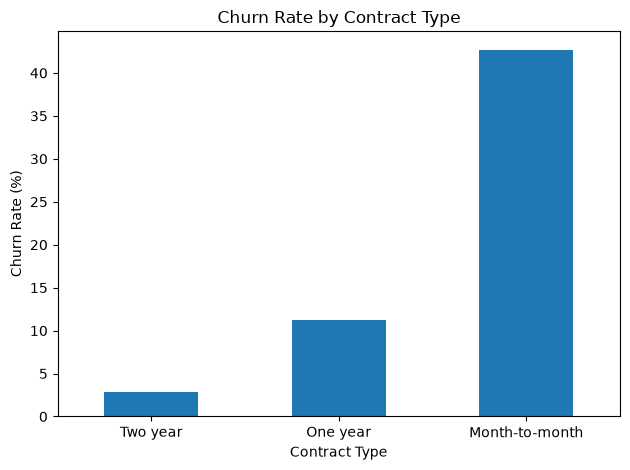

In [21]:
contract_churn["Yes"].sort_values().plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [22]:
internet_churn = pd.crosstab(
    df_clean["InternetService"],
    df_clean["Churn"],
    normalize="index"
).mul(100)

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


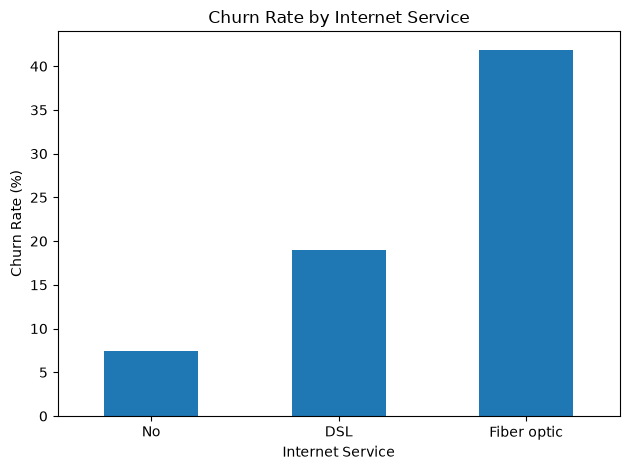

In [23]:
internet_churn["Yes"].sort_values().plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [24]:
df_clean.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(2)

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.65,61.31,2555.34
Yes,17.98,74.44,1531.80


## Initial Findings

The exploratory analysis reveals several strong patterns associated with customer churn:

- Customers on **month-to-month contracts** show a substantially higher churn rate than customers with one-year or two-year contracts.
- Customers using **fiber optic internet** have a noticeably higher churn rate compared with DSL customers or customers without internet service.
- Customers who churn tend to have a **shorter tenure**.
- Churned customers also have **higher average monthly charges**.

These findings suggest that contract type, customer tenure, internet service, and monthly charges may be important predictive features for the machine learning model.